# 02 · EDA y estadística (T-05, bloques B y C)

**Dónde:** `pipeline/src/preprocessing/eda.py`. **Por qué:** entender escalas de consumo, cartera, segmentos y quejas
antes de modelar, y probar dos hipótesis definidas antes de ver los resultados. **Cómo:** distribuciones, series
mensuales, tasas por segmento; Kruskal-Wallis (H1), chi² (H2), IC 95 % de Wilson y Spearman. **Con qué datos:** la tabla
de análisis de T-04 (recibos con etiqueta solo hasta la fecha de corte).

In [1]:
import sys, pathlib
raiz = pathlib.Path.cwd()
while not (raiz / "pipeline").exists() and raiz != raiz.parent:
    raiz = raiz.parent
sys.path.insert(0, str(raiz))
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
pd.set_option("display.max_colwidth", 120)
from pipeline.notebooks.graficas import dibujar, tabla

**Datos analizados (simulación declarada)**

,tabla,filas,descripcion
0,tomas,480,tomas de la simulación (sin parámetros del generador)
1,recibos,14400,periodos 2024-04 a 2026-09
2,lecturas,14400,sin duplicados; nulas y retrocesos marcados
3,telemetria,115200,lecturas horarias de 40 tomas
4,quejas,1400,331 textos únicos


_480 tomas y 14,400 recibos mensuales; 13,440 recibos tienen etiqueta de pago a la fecha de corte._  
`fuente: pipeline/src/preprocessing/eda.py · pipeline/notebooks/02_eda_estadistica.ipynb`

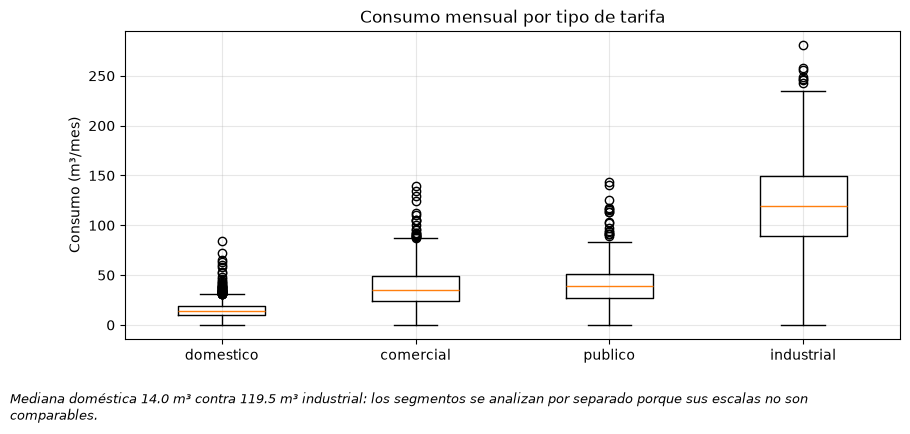

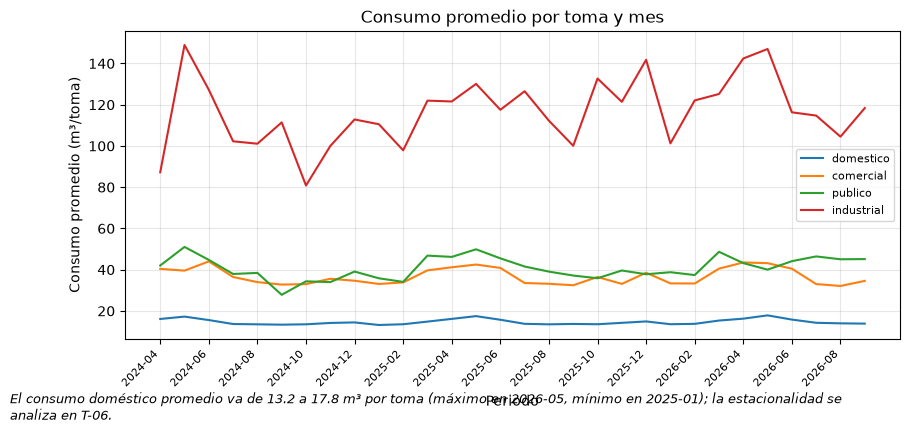

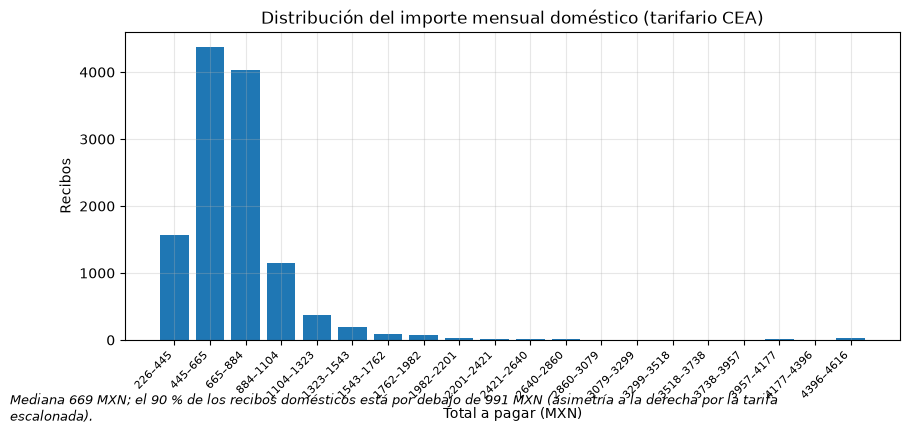

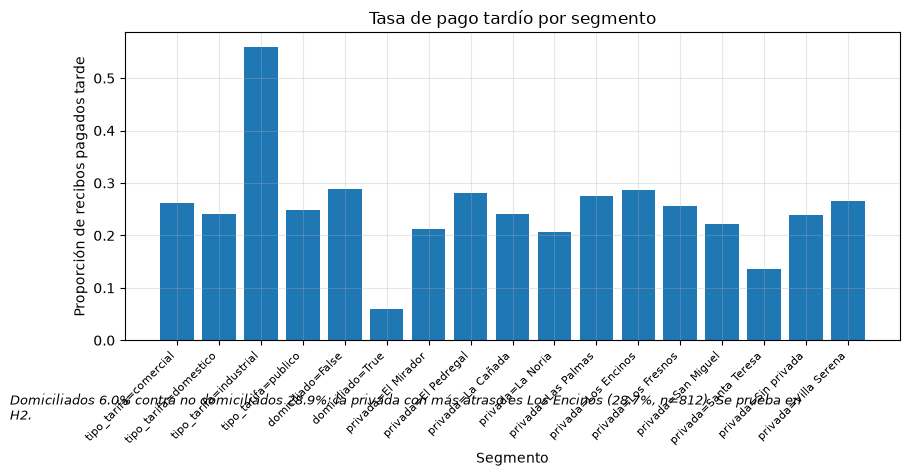

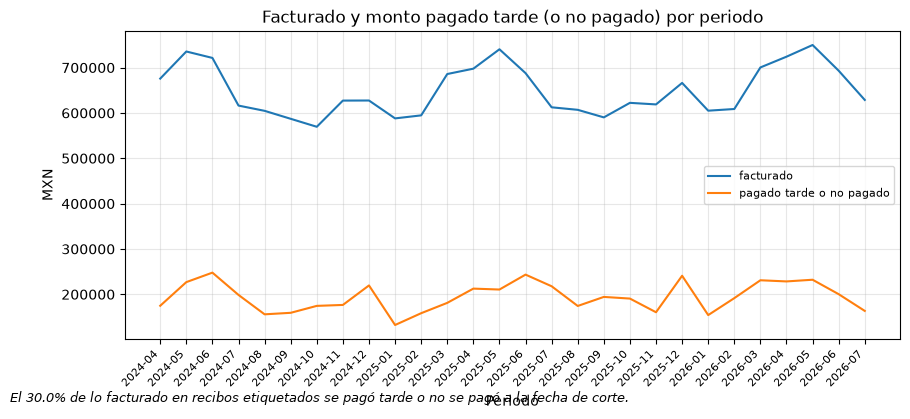

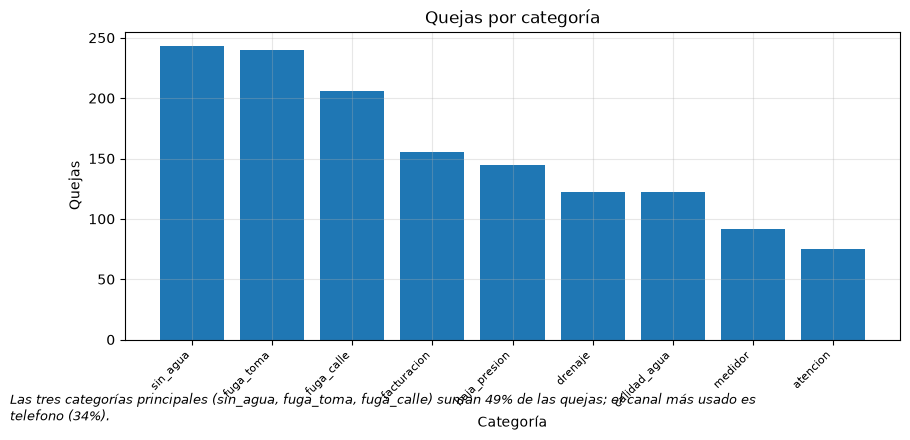

**Calidad de las lecturas de medidor**

,indicador,valor
0,lecturas nulas,114.00
1,retrocesos de medidor,57.00
2,medidores mudos,738.00
3,% inconsistentes,1.19


_1.2% de las lecturas son inconsistentes; se marcan y no se imputan._  
`fuente: pipeline/src/preprocessing/eda.py · pipeline/notebooks/02_eda_estadistica.ipynb`

In [2]:
from pipeline.src.preprocessing.eda import ejecutar
eda, estadistica = ejecutar()
for r in eda:
    dibujar(r["payload"])

## Estadística inferencial

In [3]:
for r in estadistica:
    dibujar(r["payload"])

**Pruebas de hipótesis (α = 0.05)**

,hipotesis,prueba,estadistico,gl,p_valor,efecto,decision
0,H1: el consumo doméstico difiere entre privadas,Kruskal-Wallis (promedio por toma),9.718,9,3.738106e-01,ε² = 0.002,no se rechaza H0
1,H2: pagar tarde depende de estar domiciliado,chi² de independencia,541.033,1,1.124012e-119,V de Cramér = 0.201,se rechaza H0


_H1: p = 0.374 (no se rechaza H0, ε² = 0.002). H2: p = 1.12e-119 (se rechaza H0, V = 0.201). Significancia no implica causalidad; el tamaño de efecto dice cuánto importa._  
`fuente: pipeline/src/preprocessing/eda.py · pipeline/notebooks/02_eda_estadistica.ipynb`

**Tasa de pago tardío con IC 95 % (Wilson)**

,segmento,n,tasa,ic95_inf,ic95_sup
0,tipo_tarifa=comercial,1568,0.2621,0.2409,0.2844
1,tipo_tarifa=domestico,11200,0.2402,0.2324,0.2482
2,tipo_tarifa=industrial,252,0.5595,0.4978,0.6195
3,tipo_tarifa=publico,420,0.2476,0.2088,0.2911
4,domiciliado=False,11088,0.2890,0.2806,0.2975
5,domiciliado=True,2352,0.0604,0.0514,0.0707


_El intervalo más ancho mide 12.2%: los segmentos pequeños (público, industrial) se interpretan con cautela._  
`fuente: pipeline/src/preprocessing/eda.py · pipeline/notebooks/02_eda_estadistica.ipynb`

**Correlación de Spearman por toma (n = 480)**

,variable_a,variable_b,rho,p_valor
0,consumo_medio,importe_medio,0.975,0.000000
1,consumo_medio,antiguedad_meses,0.005,0.907579
2,consumo_medio,pct_lecturas_inconsistentes,0.042,0.362621
3,consumo_medio,tasa_tardio,0.113,0.012864
4,importe_medio,antiguedad_meses,0.012,0.797066
5,importe_medio,pct_lecturas_inconsistentes,0.060,0.186151
6,importe_medio,tasa_tardio,0.116,0.011314
7,antiguedad_meses,pct_lecturas_inconsistentes,-0.019,0.683127
8,antiguedad_meses,tasa_tardio,0.082,0.072411
9,pct_lecturas_inconsistentes,tasa_tardio,-0.070,0.128298


_La variable más asociada a la tasa de pago tardío es importe_medio (ρ = 0.12, p = 0.011); consumo e importe correlacionan casi 1 por construcción de la tarifa._  
`fuente: pipeline/src/preprocessing/eda.py · pipeline/notebooks/02_eda_estadistica.ipynb`

## Conclusiones

In [4]:
for r in eda + estadistica:
    print(f"- {r['payload']['titulo']}: {r['payload']['conclusion']}")

- Datos analizados (simulación declarada): 480 tomas y 14,400 recibos mensuales; 13,440 recibos tienen etiqueta de pago a la fecha de corte.
- Consumo mensual por tipo de tarifa: Mediana doméstica 14.0 m³ contra 119.5 m³ industrial: los segmentos se analizan por separado porque sus escalas no son comparables.
- Consumo promedio por toma y mes: El consumo doméstico promedio va de 13.2 a 17.8 m³ por toma (máximo en 2026-05, mínimo en 2025-01); la estacionalidad se analiza en T-06.
- Distribución del importe mensual doméstico (tarifario CEA): Mediana 669 MXN; el 90 % de los recibos domésticos está por debajo de 991 MXN (asimetría a la derecha por la tarifa escalonada).
- Tasa de pago tardío por segmento: Domiciliados 6.0% contra no domiciliados 28.9%; la privada con más atraso es Los Encinos (28.7%, n=812). Se prueba en H2.
- Facturado y monto pagado tarde (o no pagado) por periodo: El 30.0% de lo facturado en recibos etiquetados se pagó tarde o no se pagó a la fecha de corte.
- Quejas po